# Загрузка библиотек

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, TensorDataset
import warnings

from grokking_model import GrokkingTransformer
from grokking_utils import get_modular_addition_data, get_weight_norm, plot_omnigrok_replication

warnings.filterwarnings('ignore')
torch.backends.cudnn.benchmark = True
torch.set_default_dtype(torch.float64)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")


Using cpu


# Генерация и предобработка данных

In [2]:
P = 113
FRACTION = 0.3

X_train, Y_train, X_test, Y_test, num_total = get_modular_addition_data(
    p=P, fraction=FRACTION, seed=42, device=device
)

BATCH_SIZE = 256
VAL_BATCH_SIZE = 512

train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

fixed_val_x = X_test[:VAL_BATCH_SIZE]
fixed_val_y = Y_test[:VAL_BATCH_SIZE]

print(f"Train size: {len(X_train)} | Fixed Val size: {len(fixed_val_x)}")


Train size: 3830 | Fixed Val size: 512


# Архитектура модели

In [3]:
model = GrokkingTransformer(d_vocab=P + 1).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0, betas=(0.9, 0.98))
criterion = nn.CrossEntropyLoss()

MAX_STEPS = 20000
LOG_FREQ = 10

logs = {'step': [], 'train_loss': [], 'val_loss':[], 'train_acc':[], 'val_acc': [], 'weight_norm':[]}


# Обучение

In [4]:
print("\nStarting Mini-Batch Grokking Training...")
global_step = 0
loop = tqdm(total=MAX_STEPS)

while global_step < MAX_STEPS:
    for batch_x, batch_y in train_loader:
        if global_step >= MAX_STEPS:
            break

        model.train()
        optimizer.zero_grad()

        logits_train = model(batch_x)
        train_loss = criterion(logits_train, batch_y)
        train_loss.backward()
        optimizer.step()

        if global_step % LOG_FREQ == 0:
            with torch.no_grad():
                model.eval()
                acc_train = (logits_train.argmax(dim=1) == batch_y).float().mean().item()

                logits_val = model(fixed_val_x)
                val_loss = criterion(logits_val, fixed_val_y)
                acc_val = (logits_val.argmax(dim=1) == fixed_val_y).float().mean().item()

                w_norm = get_weight_norm(model)

                logs['step'].append(global_step)
                logs['train_loss'].append(train_loss.item())
                logs['val_loss'].append(val_loss.item())
                logs['train_acc'].append(acc_train)
                logs['val_acc'].append(acc_val)
                logs['weight_norm'].append(w_norm)

                if global_step % 500 == 0:
                    loop.set_postfix(tr_L=f"{train_loss.item():.3f}", v_acc=f"{acc_val:.2f}", norm=f"{w_norm:.1f}")

        global_step += 1
        loop.update(1)

loop.close()


Starting Mini-Batch Grokking Training...


  0%|          | 0/20000 [00:00<?, ?it/s]

# Итоговые графики

Logs saved to 'grokking_minibatch_fixedval_logs.csv'


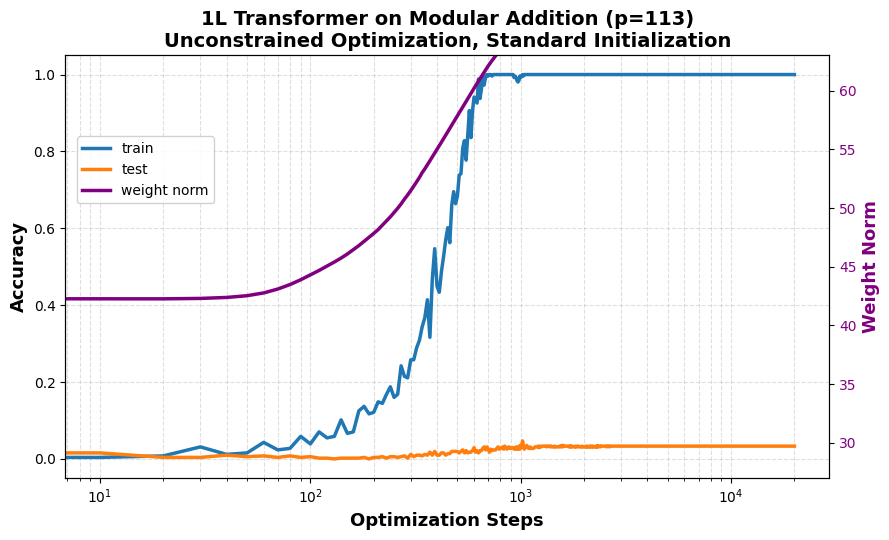

In [5]:
df_logs = pd.DataFrame(logs)
csv_name = 'grokking_minibatch_fixedval_logs.csv'
df_logs.to_csv(csv_name, index=False)
print(f"Logs saved to '{csv_name}'")

df_logs_for_plot = df_logs.rename(columns={'val_acc': 'test_acc'})
plot_omnigrok_replication(df_logs_for_plot, p=P, save_path='omnigrok_minibatch_replication.pdf')